## Categorical Independence: Chi-Square Tests

Run tests of independence to see if there is a statistically significant relationship between the core categories: Work Mode vs. High Overtime and Overtime Threshold vs. Satisfaction Category

Import the necessary libraries.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from scipy.stats import kruskal

Load the cleaned HR dataset and print the column names to remember the variables in the dataset.

In [77]:
df = pd.read_csv("../data/employee_profiles_cleaned.csv")
print(df.columns.tolist())

['employee_id', 'age', 'salary', 'promotion_eligible', 'last_training_date', 'department', 'work_experience', 'projects_completed', 'hours_worked_weekly', 'work_mode', 'last_promotion_date', 'satisfaction_score', 'overtime_hours', 'graduation_year', 'educational_background']


### Work Mode versus Overtime Hours

Perform a Chi-square test to see whether work mode and overtime hours are truly independent. Chi-square test works for categorical variables. Work mode is categorical with values on-site, hybrid, and remote. Based on the observations we had in the exploratory analysis phase, overtime hours of more than 6 hours seemed like an indicator of low satisfaction. To test this hypothesis, we can first categorize the overtime hours into two bins: High overtime hours category (over 6 hrs) or not.

In [78]:
# Create a binary indicator for the 6-hour and up overtime hours
df['high_overtime'] = df['overtime_hours'] > 6

Create the contingency table (cross-tabulation).

In [79]:
contingency_table = pd.crosstab(df['work_mode'], df['high_overtime'])
print("--- Contingency Table ---")
print(contingency_table)

--- Contingency Table ---
high_overtime  False  True 
work_mode                  
hybrid            10     24
on-site            3      6
remote             5     15


One of the assumptions for a Chi-Square test is that at least 80% of the cells have at least five observations. To check this, compute the expected values for each value in the contingency table.

In [158]:
print(pd.DataFrame(expected.T,
                   index=contingency_table.index,
                   columns=contingency_table.columns))

high_overtime     False      True 
work_mode                         
hybrid         5.428571  13.571429
on-site        8.857143  22.142857
remote         3.714286   9.285714


While the remote workers who have 6 or fewer hours of overtime, the expected value is 3.7, most of the cells have expected values of 5 or more. We decide to continue with the test.
Execute the **Chi-Square Test** for the null hypothesis that the overtime hours and work mode are independent versus the alternative hypothesis that they are dependent. Check the results at the significance level of 0.05.

In [159]:
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value:              {p_val:.4f}")
print(f"Degrees of Freedom:   {dof}")

--- Chi-Square Test Results ---
Chi-Square Statistic: 0.2368
p-value:              0.8884
Degrees of Freedom:   2


The computed p-value is 0.88 which is larger than the significance level of 0.05. We do not have enough statistical evidence to reject the null hypothesis, that is we cannot say that overtime hours and work mode are dependent. See if we can visually validate this result using a bar chart of the overtime hours categories by work mode.

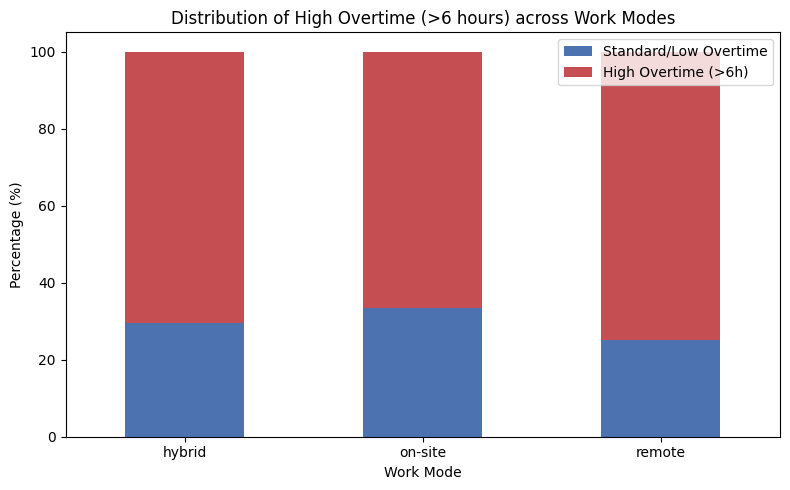

In [ ]:
contingency_table_pct = pd.crosstab(df['work_mode'], df['high_overtime'], normalize='index') * 100
contingency_table_pct.plot(kind='bar', stacked=True, color=['#4C72B0', '#C44E52'], figsize=(8,5))

plt.title('Distribution of High Overtime (>6 hours) across Work Modes')
plt.ylabel('Percentage (%)')
plt.xlabel('Work Mode')
plt.xticks(rotation=0)
plt.legend(['Standard/Low Overtime', 'High Overtime (>6h)'], loc='upper right')

plt.tight_layout()
plt.show()

High overtime hours percentages seem similar among the three different work modes.

### Satisfaction Scores versus Overtime Hours

In [321]:
# Create bins for overtime hours
bin_edges = np.linspace(0, df['overtime_hours'].max(), num=5)
df['overtime_bins'] = pd.cut(df['overtime_hours'], bins=bin_edges, include_lowest=True)
print(df['overtime_bins'].value_counts().sort_index())

overtime_bins
(-0.001, 2.45]     5
(2.45, 4.9]        7
(4.9, 7.35]       34
(7.35, 9.8]       17
Name: count, dtype: int64


Because satisfaction scores are ordinal (1–10) and overtime distributions are skewed with unequal group sizes, we use a Kruskal–Wallis test to compare satisfaction distributions across overtime workload groups. Kruskal-Wallis Test is a non-parametric statistical method used to determine if there are statistically significant differences between the medians of three or more independent groups.

In [322]:
# Prepare the data for Kruskal-Wallis test (Group the satisfaction scores based on the overtime bins)
groups = [group['satisfaction_score'].values
    for _, group in df.groupby('overtime_bins')]

# Execute the Kruskal-Wallis Test
h_stat, p_val = kruskal(*groups)

# Print the results
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.4f}")

H-statistic: 1.9018
p-value: 0.5930


In [323]:
from scipy.stats import spearmanr

rho, p_val = spearmanr(
    df['overtime_hours'],
    df['satisfaction_score']
)

print(rho, p_val)

-0.03771475900381802 0.7691693996994993


## Satisfaction Scores versus Departments

During the exploratory data analysis, we observed that the median satisfaction score for the HR department is lower than that of other departments and most of the satisfaction scores in Marketing are lower than the median score of 6. If the assumptions are met, **One-Way ANOVA** is a viable way to test if at least one of the mean satisfaction scores across different departments is statistically significant.

However, before we proceed, we need to check if the data meets the assumptions. independence (assumed from data collection), approximate normality within groups, homogeneity of variances.

Perform Levene test to check for homogeneity of variances between groups.

In [332]:
from scipy.stats import levene

groups = [df[df['department'] == dept]['satisfaction_score']
    for dept in df['department'].unique()]

stat, p = levene(*groups)
print(p)

0.8488346296789501


In [346]:
from scipy.stats import shapiro

for dept in df['department'].unique():
    scores = df[df['department'] == dept]['satisfaction_score']

    stat, p_val = shapiro(scores)

    print(f"{dept}")
    print(f"n = {len(scores)}")
    print(f"Shapiro p-value = {p_val:.4f}")
    print("-" * 30)

Finance
n = 30
Shapiro p-value = 0.0029
------------------------------
Hr
n = 6
Shapiro p-value = 0.0848
------------------------------
Engineering
n = 18
Shapiro p-value = 0.2138
------------------------------
Marketing
n = 9
Shapiro p-value = 0.0010
------------------------------


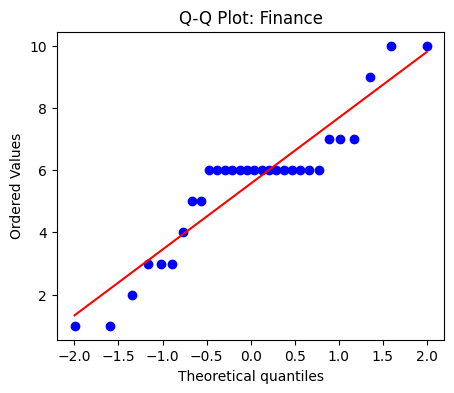

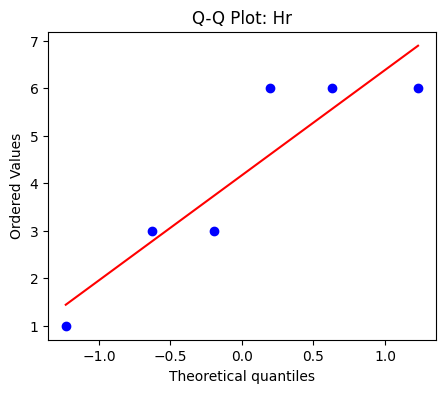

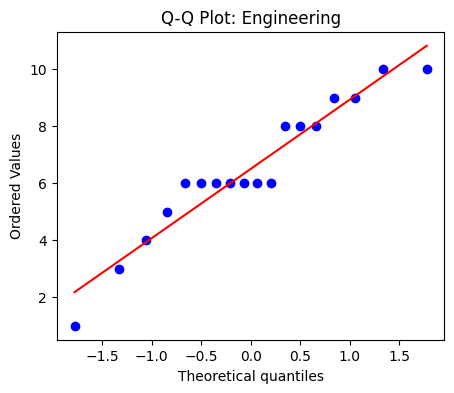

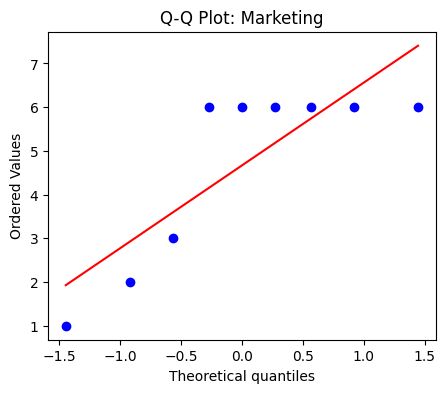

In [347]:
from scipy.stats import probplot
import matplotlib.pyplot as plt

departments = df['department'].unique()

for dept in departments:
    scores = df[df['department'] == dept]['satisfaction_score']

    plt.figure(figsize=(5,4))
    probplot(scores, dist='norm', plot=plt)

    plt.title(f'Q-Q Plot: {dept}')
    plt.show()

In [348]:
#Group the data by department for the ANOVA input by extracting the satisfaction scores for each specific department cohort.
for dept in df['department'].unique():
    scores = df[df['department'] == dept]['satisfaction_score'].values
    print(f"Department: {dept} (Total: {len(scores)})")
    print(scores)
    print("-" * 40)

Department: Finance (Total: 30)
[ 6.  6.  7.  6.  2.  7.  6.  6.  7.  3.  6.  6.  3.  9.  5.  1.  6.  4.
  6.  6.  6.  6. 10.  5. 10.  6.  6.  3.  1.  6.]
----------------------------------------
Department: Hr (Total: 6)
[3. 3. 6. 6. 1. 6.]
----------------------------------------
Department: Engineering (Total: 18)
[ 4.  3.  6. 10. 10.  6.  1.  8.  8.  6.  6.  6.  9.  6.  5.  8.  6.  9.]
----------------------------------------
Department: Marketing (Total: 9)
[6. 1. 2. 6. 6. 3. 6. 6. 6.]
----------------------------------------


Although the Leven test suggest homogeneous variance among the groups, the Sapiro test has mized results among departments, given the very small sample sizes, 6 and 9, respectively, for the HR and Marketing departments, and the bounded values for the satisfaction scores (1-10), it might be good to use the Kruskal-Wallis test again.

In [356]:
from scipy.stats import kruskal

groups = [df[df['department'] == dept]['satisfaction_score']
    for dept in df['department'].unique()]

h_stat, p_val = kruskal(*groups)

print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.4f}")

H-statistic: 6.1483
p-value: 0.1046


Execute the One-Way ANOVA

In [357]:
groups = [df[df['department'] == dept]['satisfaction_score'] for dept in df['department'].unique()]
f_stat, p_val = f_oneway(*groups)

print("--- One-Way ANOVA Results ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"p-value:     {p_val:.4f}")

--- One-Way ANOVA Results ---
F-Statistic: 2.3495
p-value:     0.0816


Interpret the result.

 Create the boxplot again to see how the distribution of satisfaction scores look by department.

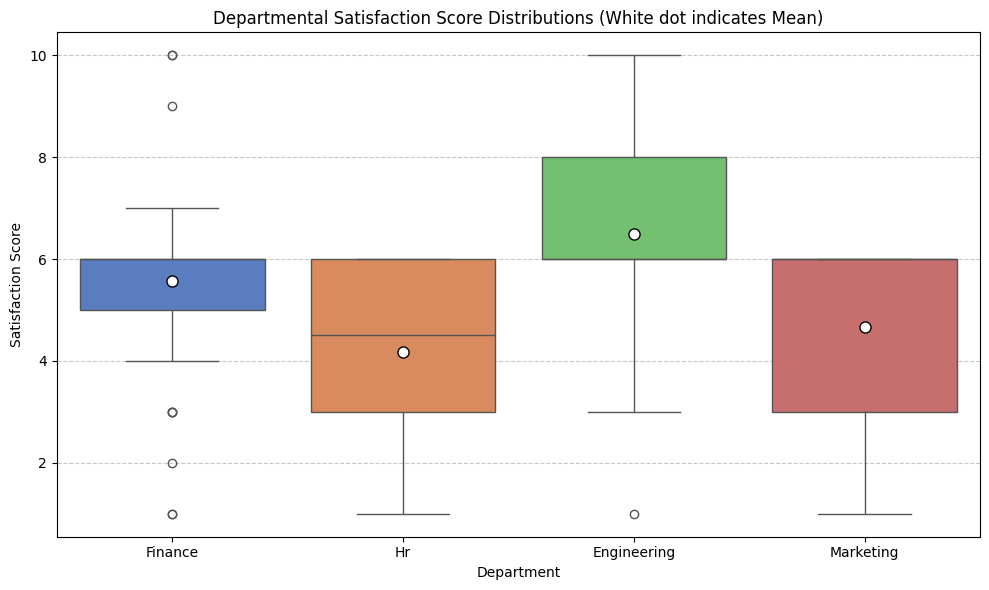

In [359]:
plt.figure(figsize=(10,6))
sns.boxplot(x='department',y='satisfaction_score',data=df, 
    hue='department',legend=False,palette='muted',showmeans=True, 
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

plt.title('Departmental Satisfaction Score Distributions (White dot indicates Mean)')
plt.ylabel('Satisfaction Score')
plt.xlabel('Department')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Even though the median satisfaction score is lower than the median value of 6 and most of the scores in the marketing department are lower than the median, the sample size of both departments are much lower than that of fincance and engineering. It would be important to collect more data for HR and Marketing to gain more insight.Gathering the salary data for the discarded data is recommended, so that such a big amount is not removed from the data set and rerun the whole pipeline to see how the results are impacted.